In [1]:
import base64
from io import BytesIO

import pandas as pd
import rdkit
from IPython.display import HTML
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor
from stereomolgraph import Bond, StereoMolGraph
from stereomolgraph.algorithms.symmetry import bond_symmetry_number

rdkit.__version__

'2026.03.1'

In [2]:
smiles_bond = [
    ("CC(C)(C)C(CC)(CC)CC", (1, 4)),
    ("CC([C@H](F)C)([C@H](F)C)[C@H](F)C", (0, 1)),
    ("C[C@@H](C([C@@H](C)F)(C)[C@H](C)F)F", (2, 6)),
    ("CCC(CC)(CC)O[H]", (7, 2)),
    ("C[C@H](F)C([C@@H](F)C)([C@@H](F)C)O[H]", (10, 3)),
    ("C[C@H](F)C([C@@H](F)C)([C@H](F)C)O[H]", (10, 3)),
    ("CC1=CC=CC=C1", (0, 1)),
    ("OC1=CC=CC=C1", (0, 1)),
    ("OC12CCC(CC2)CC1", (0, 1)),
    ("OC12C[C@H](C([C@@H](C2)F)[C@@H](C1)F)F", (0, 1)),
    ("OC12C[C@H](C([C@@H](C2)F)[C@H](C1)F)F", (0, 1)),
    ("OC1=CC=C(C2=C(F)C=CC=C2I)C=C1", (0, 1)),
]

image,bond_symmetry_number,smiles
,3,CC(C)(C)C(CC)(CC)CC
,3,CC([C@H](F)C)([C@H](F)C)[C@H](F)C
,3,C[C@@H](C([C@@H](C)F)(C)[C@H](C)F)F
,3,CCC(CC)(CC)O[H]
,3,C[C@H](F)C([C@@H](F)C)([C@@H](F)C)O[H]
,1,C[C@H](F)C([C@@H](F)C)([C@H](F)C)O[H]
,6,CC1=CC=CC=C1
,2,OC1=CC=CC=C1
,3,OC12CCC(CC2)CC1
,3,OC12C[C@H](C([C@@H](C2)F)[C@@H](C1)F)F

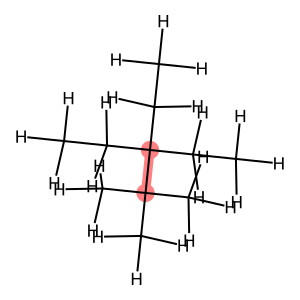
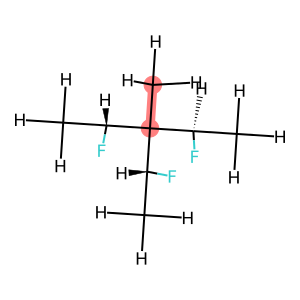
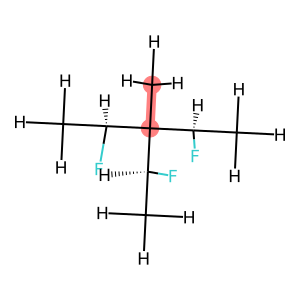
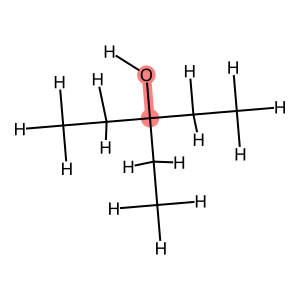
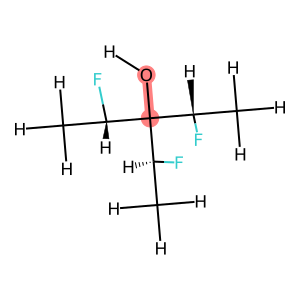
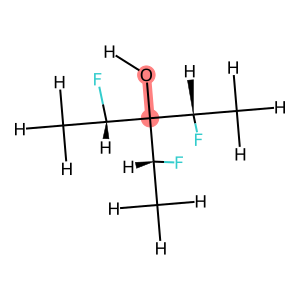
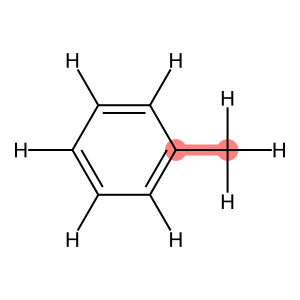
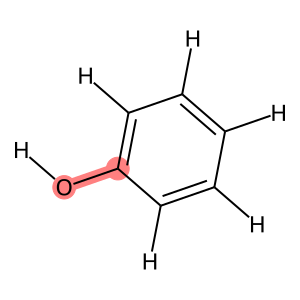
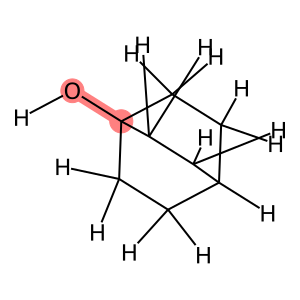
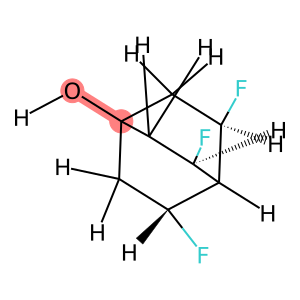
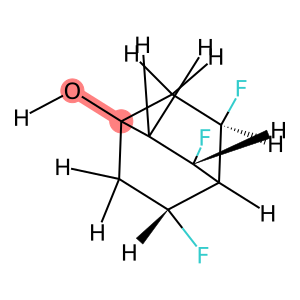
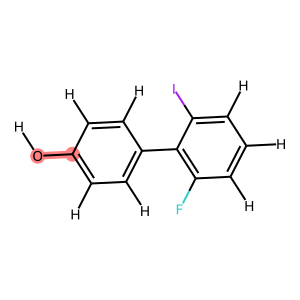
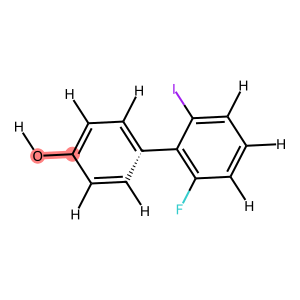

In [3]:
from stereomolgraph.stereodescriptors import AtropBond


def rdmol_with_h(smiles: str) -> Chem.Mol:
    mol = Chem.AddHs(Chem.MolFromSmiles(smiles))
    rdDepictor.Compute2DCoords(mol)
    return mol


def bond_image_html(
    rdmol: Chem.Mol, bond: Bond, size: tuple[int, int] = (300, 300)
) -> str:
    bond = Bond(bond)
    draw_mol = Chem.Mol(rdmol)
    rdDepictor.Compute2DCoords(draw_mol)
    highlight_bond = draw_mol.GetBondBetweenAtoms(*bond)
    if highlight_bond is None:
        raise ValueError(f"Bond {tuple(sorted(bond))} not found in molecule")

    image = Draw.MolToImage(
        draw_mol,
        size=size,
        highlightAtoms=list(bond),
        highlightBonds=[highlight_bond.GetIdx()],
    )
    buffer = BytesIO()
    image.save(buffer, format="PNG")
    png_base64 = base64.b64encode(buffer.getvalue()).decode("ascii")
    return (
        f'<img src="data:image/png;base64,{png_base64}" width="{size[0]}" />'
    )


def result_row(
    smiles: str, bond: Bond, rdmol: Chem.Mol, smg: StereoMolGraph
) -> dict[str, object]:
    return {
        "image": bond_image_html(rdmol, bond),
        "bond_symmetry_number": bond_symmetry_number(smg, bond),
        "smiles": smiles,
    }


rows = []
for smiles, bond in smiles_bond:
    bond = Bond(bond)
    rdmol = rdmol_with_h(smiles)
    smg = StereoMolGraph.from_rdmol(rdmol, stereo_complete=True)
    rows.append(result_row(smiles, bond, rdmol, smg))

atrop_smiles = "OC1=CC=C(C2=C(F)C=CC=C2I)C=C1"
atrop_smg = StereoMolGraph.from_rdmol(
    rdmol_with_h(atrop_smiles),
    stereo_complete=True,
    resonance=False,
    lone_pair_stereo=False,
    use_atom_map_number=False,
    # keep defaults explicit only where the notebook relies on them
)
atrop_smg.set_bond_stereo(AtropBond((3, 13, 4, 5, 6, 11), 1))
atrop_rdmol = atrop_smg.to_rdmol()
rdDepictor.Compute2DCoords(atrop_rdmol)
rows.append(result_row("", Bond((0, 1)), atrop_rdmol, atrop_smg))

results = pd.DataFrame(rows)
HTML(results.to_html(index=False, escape=False))